# WattCast — Exploratory Data Analysis

Dataset: UCI Appliances Energy Prediction (Candanedo et al.) — 19,735 rows, 29 columns,
10-minute intervals, 2016-01-11 to 2016-05-27.

This notebook validates the time index, characterizes the daily/weekly rhythm of the
`Appliances` target, checks for outliers, decomposes trend/seasonality, tests
stationarity, and reviews sensor correlations — establishing what's usable as a feature
before Phase 2 (leakage-checked feature engineering).

## 1. Setup & Imports

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller

from config.paths import RAW_DATA_PATH

## 2. Load Data & Validate Timestamps

Load the raw CSV, parse `date` to `datetime64`, sort chronologically, and confirm the
time index is well-formed before it's trusted for any sequence-dependent analysis.

In [3]:
df = pd.read_csv(RAW_DATA_PATH)
df.head(2)

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.7900,19.79,44.73,19.0,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.7225,19.79,44.79,19.0,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  str    
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9           19

In [5]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

In [6]:
duplicate_count = df["date"].duplicated().sum()
is_increasing = df["date"].is_monotonic_increasing

time_diff = df["date"].diff()
expected_gap = pd.Timedelta(minutes=10)
cadence_violations = time_diff[time_diff.notna() & (time_diff != expected_gap)]

print("Duplicate timestamps:", duplicate_count)
print("Strictly increasing:", is_increasing)
print("Cadence violations:", len(cadence_violations))

Duplicate timestamps: 0
Strictly increasing: True
Cadence violations: 0


No duplicate timestamps, strictly increasing, and every gap is exactly 10 minutes across
all 19,734 intervals. The dataset is pre-cleaned — timestamps are fully trustworthy, so
rolling/lag features in Phase 2 don't need gap-aware logic.

`date` is now promoted to the index.

In [7]:
df = df.set_index("date")

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Nulls:", df.isna().sum().sum())

Rows: 19735
Columns: 28
Nulls: 0


Zero nulls across all 29 columns. Note: `rv1` and `rv2` are deliberately injected
random-noise columns from the original dataset authors — used later as a sanity check on
the correlation methodology.

## 3. Daily & Weekly Seasonality

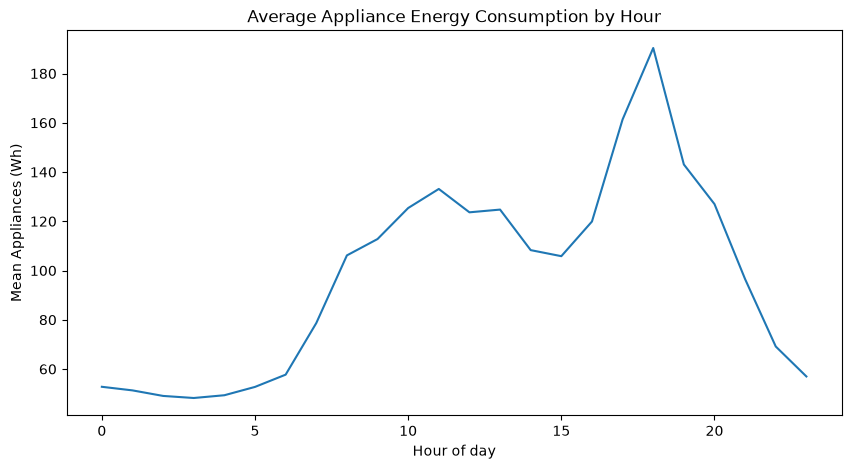

In [8]:
hourly_profile = df.groupby(df.index.hour)["Appliances"].mean()
hourly_profile.plot(
    kind="line", figsize=(10, 5),
    title="Average Appliance Energy Consumption by Hour"
)
plt.xlabel("Hour of day")
plt.ylabel("Mean Appliances (Wh)")
plt.show()

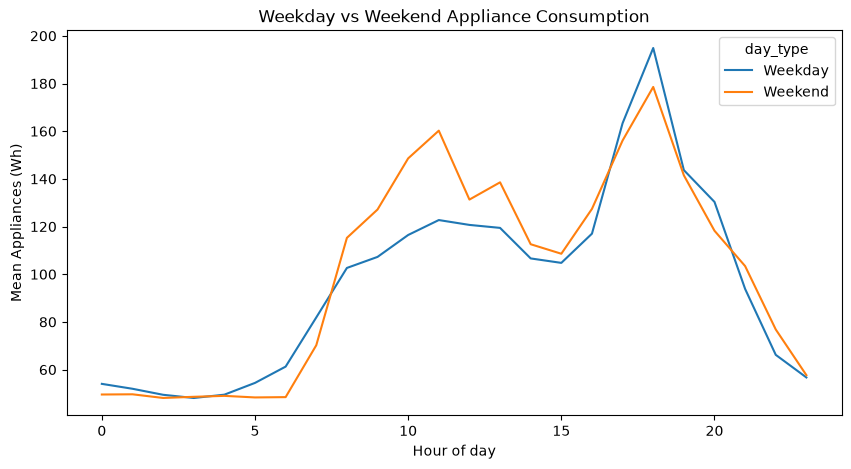

In [9]:
df["day_type"] = np.where(df.index.dayofweek >= 5, "Weekend", "Weekday")

weekday_profile = (
    df.groupby(["day_type", df.index.hour])["Appliances"]
    .mean()
    .unstack(level=0)
)
weekday_profile.plot(
    kind="line", figsize=(10, 5),
    title="Weekday vs Weekend Appliance Consumption"
)
plt.xlabel("Hour of day")
plt.ylabel("Mean Appliances (Wh)")
plt.show()

Clear non-random daily shape: overnight trough (00:00–05:00), morning rise (06:00–08:00),
a mid-morning local peak (~11:00), a midday plateau, and a strong evening peak (~18:00).

Weekday and weekend profiles are *not* a constant offset — the shape itself changes.
Weekend consumption is substantially higher through late morning/early afternoon
(occupants home longer); the weekday evening peak is slightly higher and more
concentrated. Overnight hours are nearly identical regardless of day type.

## 4. ACF / PACF

At a 10-minute cadence: 6 lags = 1 hour, 144 lags = 1 day, 1008 lags = 1 week.

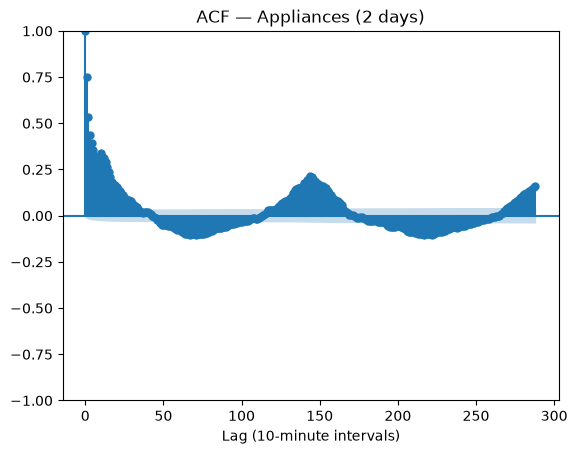

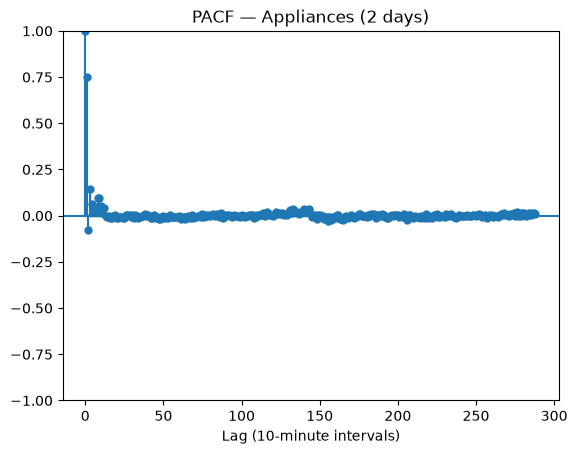

In [10]:
plot_acf(df["Appliances"], lags=288, alpha=0.05, fft=True)
plt.title("ACF — Appliances (2 days)")
plt.xlabel("Lag (10-minute intervals)")
plt.show()

plot_pacf(df["Appliances"], lags=288, alpha=0.05, method="ywm")
plt.title("PACF — Appliances (2 days)")
plt.xlabel("Lag (10-minute intervals)")
plt.show()

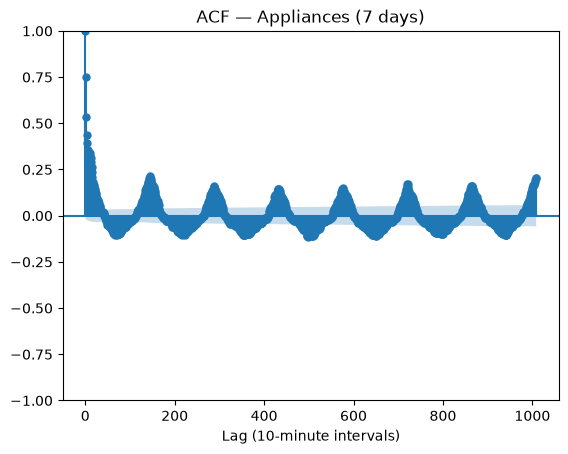

In [11]:
plot_acf(df["Appliances"], lags=1008, alpha=0.05, fft=True)
plt.title("ACF — Appliances (7 days)")
plt.xlabel("Lag (10-minute intervals)")
plt.show()

**ACF:** sharp decay from lag 1, near-zero by ~lag 40–50 (7–8 hrs), then a clear bump at
lag 144 (24 hrs) that repeats at every daily multiple out to lag 1008 (7 days) with
roughly constant height. The daily cycle persists undiminished across the week — this
alone doesn't prove an *independent* weekly effect (that evidence came from the
weekday/weekend grouped means in §3), since a repeating daily bump is also what a
7×-repeated daily cycle looks like.

**PACF:** collapses to ~0 by lag 2–3, including at lag 144 — meaning lag 144 adds no
independent *linear* information beyond the short lags already in the chain. PACF only
tests linear redundancy through an autoregressive lens; a nonlinear model (Random Forest,
LSTM) may still find real signal there.

**Decision:** keep `lag_144` as an empirical candidate feature for Phase 2, not a
foregone inclusion or exclusion — alongside `hour_sin`/`hour_cos`, which encode calendar
position rather than realized historical behavior and are therefore complementary, not
redundant.

## 5. Outlier Investigation

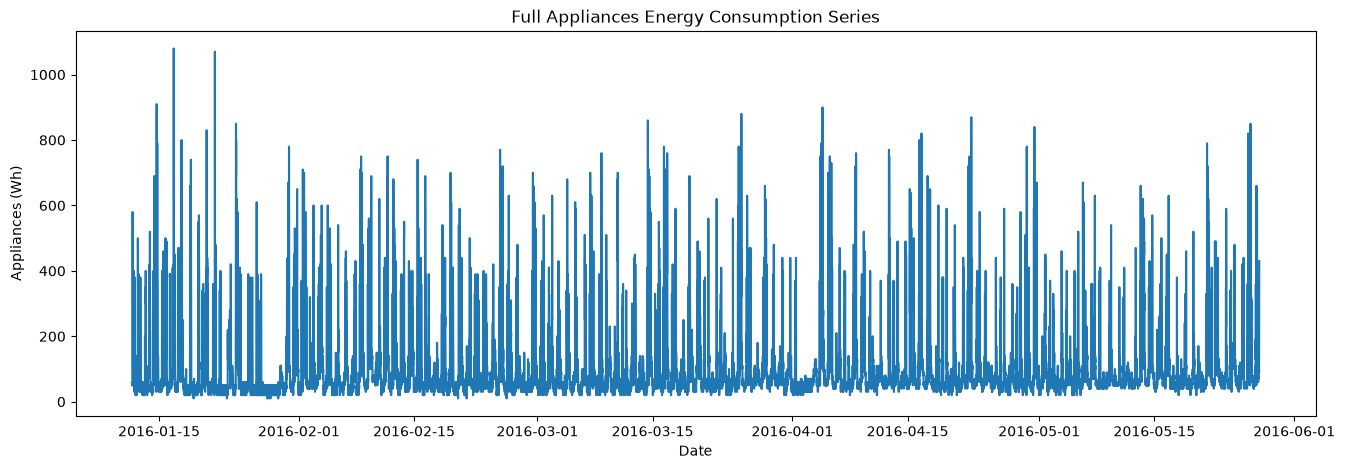

In [12]:
plt.figure(figsize=(16, 5))
plt.plot(df.index, df["Appliances"])
plt.title("Full Appliances Energy Consumption Series")
plt.xlabel("Date")
plt.ylabel("Appliances (Wh)")
plt.show()

In [13]:
window = 144  # 1 day, backward-looking
rolling_q1 = df["Appliances"].rolling(window).quantile(0.25)
rolling_q3 = df["Appliances"].rolling(window).quantile(0.75)
rolling_iqr = rolling_q3 - rolling_q1
upper_bound = rolling_q3 + 1.5 * rolling_iqr

outlier_mask = df["Appliances"] > upper_bound

print("Flagged points:", outlier_mask.sum())
print("Percentage flagged: {:.2f}%".format(outlier_mask.mean() * 100))

Flagged points: 2223
Percentage flagged: 11.26%


Rolling IQR flags **11.26%** of observations — far too high a rate to represent genuine
rare anomalies. This is the rule capturing the series' normal bursty variability, not
errors, so it's worth inspecting the flagged and extreme points directly rather than
trusting the rule.

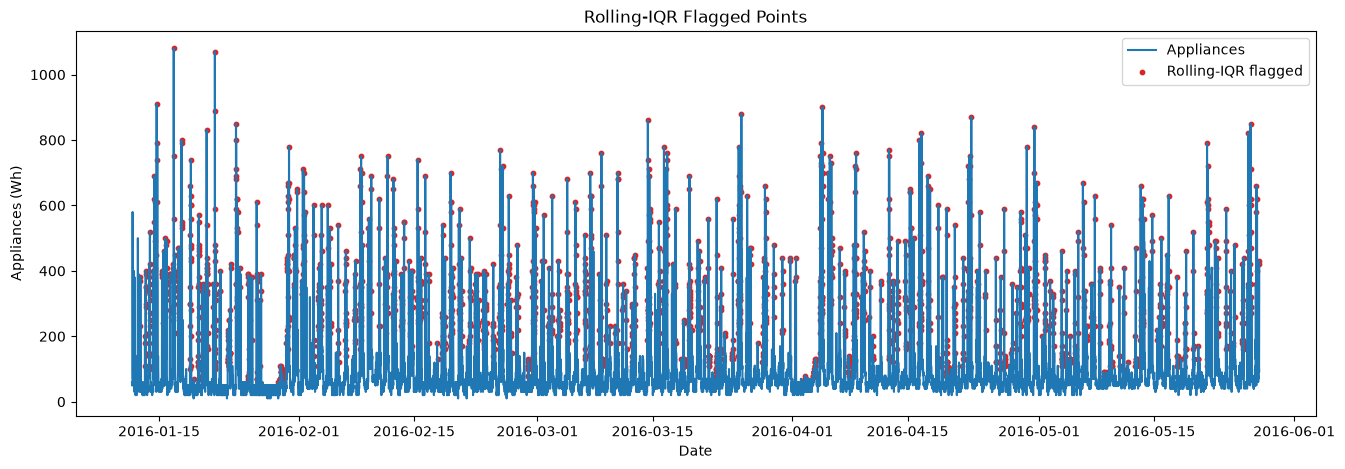

In [14]:
plt.figure(figsize=(16, 5))
plt.plot(df.index, df["Appliances"], label="Appliances")
plt.scatter(
    df.index[outlier_mask], df.loc[outlier_mask, "Appliances"],
    color="tab:red", s=10, label="Rolling-IQR flagged"
)
plt.title("Rolling-IQR Flagged Points")
plt.xlabel("Date")
plt.ylabel("Appliances (Wh)")
plt.legend()
plt.show()

In [15]:
extreme_threshold = df["Appliances"].quantile(0.995)
extreme_mask = df["Appliances"] >= extreme_threshold

previous_extreme = extreme_mask.shift(1, fill_value=False)
next_extreme = extreme_mask.shift(-1, fill_value=False)
isolated_extremes = df[extreme_mask & ~previous_extreme & ~next_extreme]

print("Maximum:", df["Appliances"].max())
print("99.5th percentile threshold:", extreme_threshold)
print("Isolated extreme points (no extreme neighbor):", len(isolated_extremes))

Maximum: 1080
99.5th percentile threshold: 660.0
Isolated extreme points (no extreme neighbor): 56


In [16]:
max_time = df["Appliances"].idxmax()
context = df.loc[
    max_time - pd.Timedelta(hours=2): max_time + pd.Timedelta(hours=2),
    ["Appliances"]
]
print("Context around the maximum (", max_time, "):")
print(context)

Context around the maximum ( 2016-01-16 18:50:00 ):
                     Appliances
date                           
2016-01-16 16:50:00          80
2016-01-16 17:00:00          80
2016-01-16 17:10:00         150
2016-01-16 17:20:00         380
2016-01-16 17:30:00         290
2016-01-16 17:40:00         270
2016-01-16 17:50:00         420
2016-01-16 18:00:00         280
2016-01-16 18:10:00         300
2016-01-16 18:20:00         350
2016-01-16 18:30:00         270
2016-01-16 18:40:00         560
2016-01-16 18:50:00        1080
2016-01-16 19:00:00         750
2016-01-16 19:10:00         390
2016-01-16 19:20:00         350
2016-01-16 19:30:00         340
2016-01-16 19:40:00         290
2016-01-16 19:50:00         230
2016-01-16 20:00:00         120
2016-01-16 20:10:00         110
2016-01-16 20:20:00         100
2016-01-16 20:30:00         110
2016-01-16 20:40:00         130
2016-01-16 20:50:00         140


Manual inspection of extreme values (max = 1080, several readings > 800–900), both
sustained multi-hour high-usage runs and isolated 99.5th-percentile points: every case
sits inside a smooth, physically plausible local ramp-up/ramp-down — no context-free
spikes, no stuck/flat sensor plateaus, no physically impossible values.

**Decision:** retain the raw target unmodified. No clipping, no removal. High-consumption
events are real, important signal the model must learn, not noise to clean away.

## 6. STL Decomposition (Trend / Seasonal / Residual)

Period = 144 (the confirmed daily cycle).

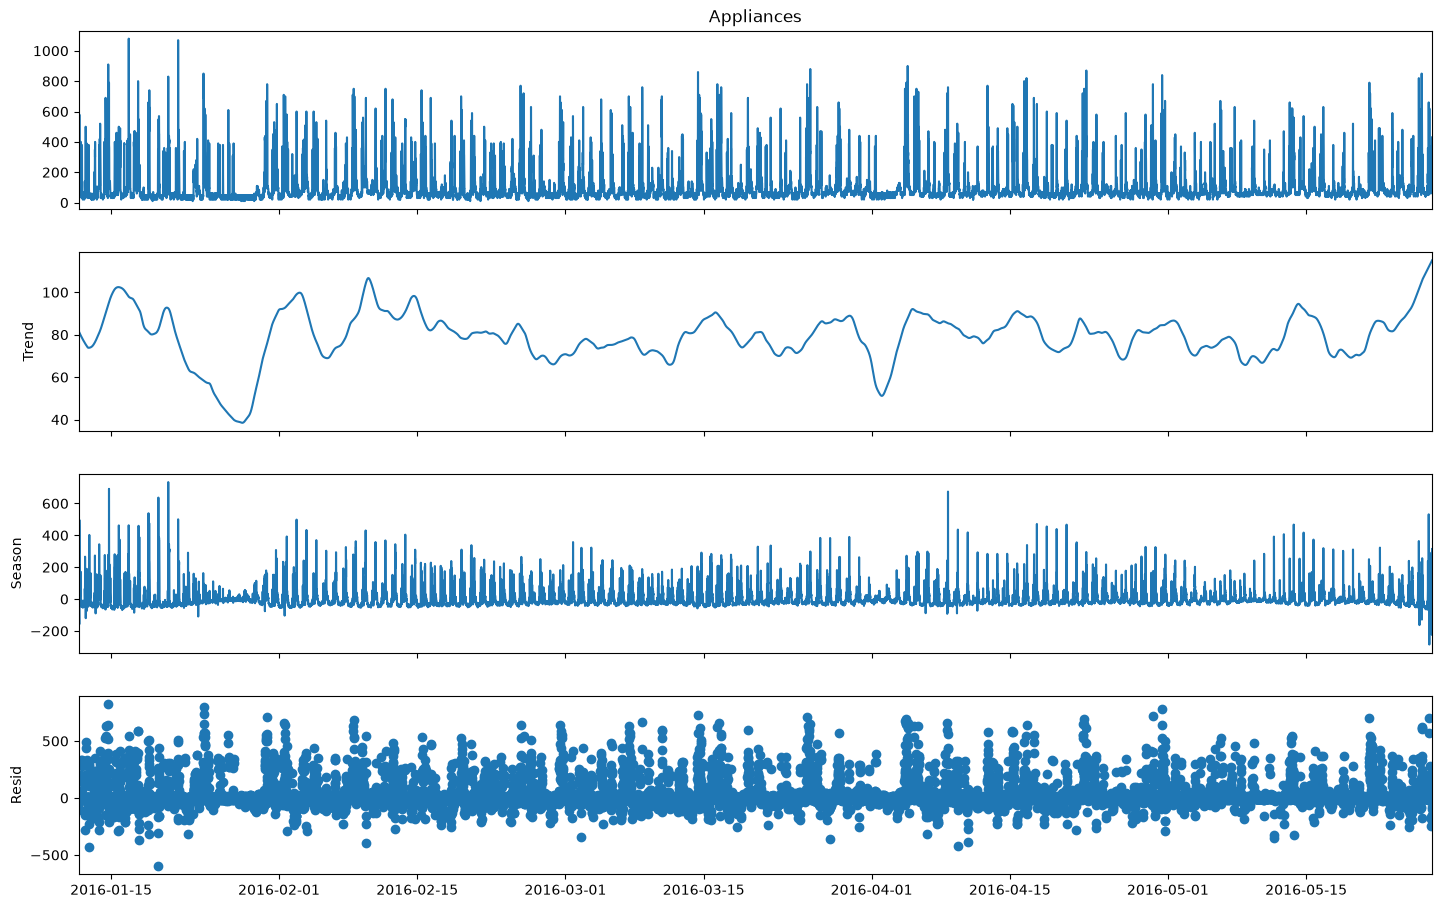

In [17]:
result_naive = STL(df["Appliances"], period=144, robust=False).fit()
result_robust = STL(df["Appliances"], period=144, robust=True).fit()

fig = result_robust.plot()
fig.set_size_inches(16, 10)
plt.show()

In [18]:
amp_naive = result_naive.seasonal.max() - result_naive.seasonal.min()
amp_robust = result_robust.seasonal.max() - result_robust.seasonal.min()

print("Seasonal amplitude, robust=False:", amp_naive)
print("Seasonal amplitude, robust=True :", amp_robust)

Seasonal amplitude, robust=False: 702.9895106826181
Seasonal amplitude, robust=True : 1019.0136150499667


`robust=False` let individual extreme (but legitimate) events visibly distort the trend
estimate, swinging it on a day-to-day timescale instead of a genuine slow-moving level.
`robust=True` produces a materially smoother, more interpretable trend — used from here
on.

Raw seasonal `max − min` amplitude is itself fragile — dominated by the same handful of
extreme points that inflated the outlier flag rate above. A robust per-day **P90−P10**
metric is used instead, computed on the interior of the series (dropping the first/last
period, which STL can't estimate as reliably).

In [19]:
interior_seasonal = result_robust.seasonal.iloc[144:-144]

daily_amplitude = (
    interior_seasonal
    .groupby(interior_seasonal.index.date)
    .agg(lambda x: x.quantile(0.90) - x.quantile(0.10))
)
daily_amplitude.index = pd.to_datetime(daily_amplitude.index)

n = len(daily_amplitude)
early = daily_amplitude.iloc[: n // 3]
middle = daily_amplitude.iloc[n // 3: 2 * n // 3]
late = daily_amplitude.iloc[2 * n // 3:]

print("Median daily P90-P10 seasonal amplitude")
print("Early :", early.median())
print("Middle:", middle.median())
print("Late  :", late.median())

Median daily P90-P10 seasonal amplitude
Early : 93.74023129747542
Middle: 74.28204691906906
Late  : 60.4540800120712


Daily seasonal amplitude declines **monotonically** across the study window — Early
(median ~94) → Middle (~74) → Late (~60) — plausibly tracking winter→spring
daylight/temperature change (a hypothesis, not yet cross-checked against `T_out`).

**Overall conclusion:** the daily rhythm's *shape* is stable across all 4.5 months (same
overnight-low → morning-rise → evening-peak structure throughout), but its *amplitude*
drifts over the study period — a more precise finding than either "seasonality is
stable" or "seasonality is unstable" alone.

## 7. Stationarity (ADF Test)

In [20]:
adf_result = adfuller(df["Appliances"], regression="ct", autolag="AIC", result_object=True)

print("ADF statistic:", adf_result.statistic)
print("p-value:", adf_result.pvalue)
print("Used lags:", adf_result.lags)
print("Critical values:", dict(adf_result.critical_values))

ADF statistic: -21.61567662110765
p-value: 0.0
Used lags: 11
Critical values: {'1%': np.float64(-3.959229085418433), '5%': np.float64(-3.410712626287175), '10%': np.float64(-3.1271811057680763)}


Statistic ≈ −21.6, p ≈ 0.0 — decisively below even the 1% critical value (−3.96). Strong
rejection of the unit-root null.

This isn't a contradiction of the STL trend drift above — they answer different
questions. STL's trend describes *bounded, mean-reverting local-level movement* (the
series reliably swings back down after every peak). ADF's unit-root question is about
*unbounded stochastic drift* — wandering arbitrarily far from any fixed level given
enough time. `Appliances` does the former, not the latter.

Baselines (Linear Regression, Random Forest) don't require stationarity, so no
differencing is applied to the target.

## 8. Sensor Correlation

Pearson correlation of every numeric feature against `Appliances`, same-timestamp.

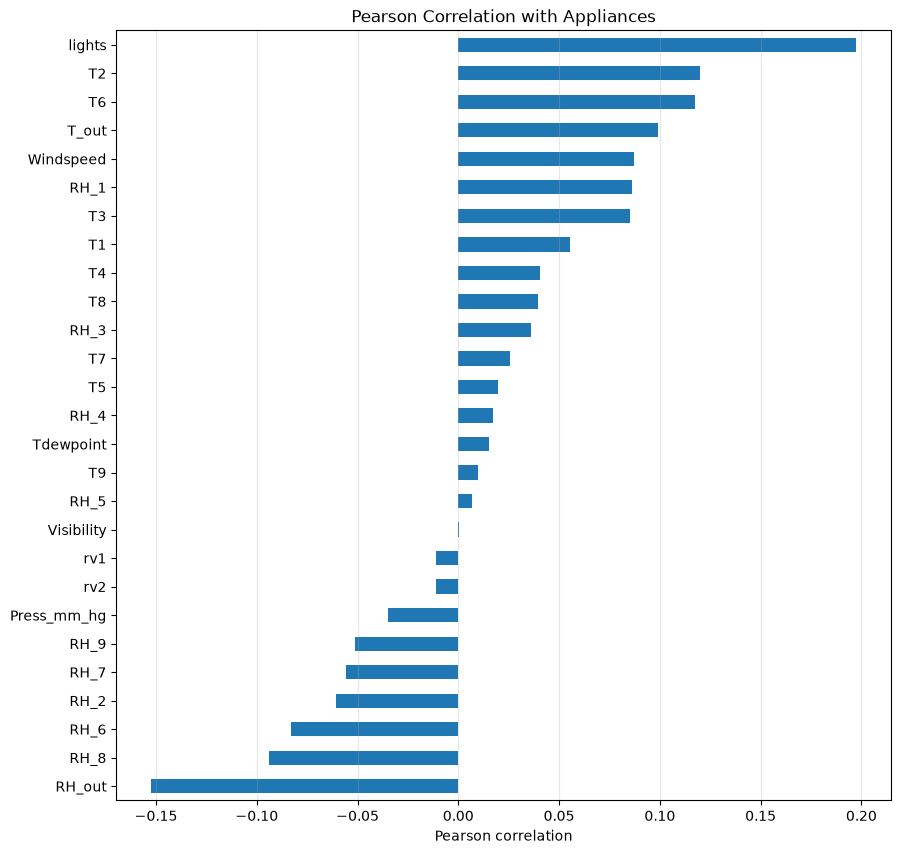

rv1 correlation: -0.011144917533634427
rv2 correlation: -0.011144917533634427


In [21]:
numeric_df = df.select_dtypes(include="number")
sensor_corr = numeric_df.corr()["Appliances"].drop("Appliances").sort_values()

sensor_corr.plot(kind="barh", figsize=(10, 10))
plt.title("Pearson Correlation with Appliances")
plt.xlabel("Pearson correlation")
plt.grid(axis="x", alpha=0.3)
plt.show()

print("rv1 correlation:", sensor_corr["rv1"])
print("rv2 correlation:", sensor_corr["rv2"])

All correlations are weak — strongest are `RH_out` (−0.15) and `time_of_day` (+0.22);
every sensor sits under |0.25|. `rv1`/`rv2` (deliberately injected noise columns) show
near-zero correlation as expected, confirming the methodology is behaving correctly.

No individual sensor linearly explains much of the target on its own — the real
predictive structure is temporal/dynamic (daily rhythm, recent history), not simple
contemporaneous sensor relationships. This supports prioritizing time-based and lag
features over raw sensor values in Phase 2.

## 9. Forecast Framing (governs Phase 2)

WattCast's architecture (sliding-window context buffer, sequence models) is **true
forecasting**, not nowcasting: predicting `Appliances(t+h)` using only information
available at or before the forecast origin.

**Rule:** any feature must be available at or before the moment the forecast is
generated.
- Contemporaneous sensor readings at the *target* timestamp — including `lights` and
  every `T*`/`RH*` column — are **not** usable in raw same-timestamp form, only their
  lagged/historical values are.
- Calendar-derived features (`hour_sin`/`hour_cos`, day-of-week, etc.) for the *target*
  timestamp **are** usable, since calendar position is knowable in advance regardless of
  horizon.

The §8 correlation results remain valid as EDA — informing which sensors are worth
lagging into features later — but must not be read as license to use those same-timestamp
values directly.

## Summary

The dataset has regular 10-minute timestamps with no integrity problems, so temporal
ordering is trustworthy for modeling. The target shows a strong, persistent daily cycle
whose shape stays stable across the 4.5-month window but whose amplitude drifts downward
over time (plausibly seasonal). ACF confirms recurring daily dependence; PACF shows lag
144 carries no independent *linear* signal, so it's kept only as an empirical candidate
feature. Large consumption values were investigated and found to be real, physically
plausible demand, not sensor error — the target is used unmodified. The ADF test strongly
rejects a unit root despite the STL trend drift, since STL describes bounded,
mean-reverting movement rather than unbounded stochastic drift. Same-time sensor
correlations are uniformly weak, meaning predictive structure lies in temporal patterns
and recent history rather than raw contemporaneous readings. Because WattCast is a true
forecasting system, only information available at or before the forecast origin may be
used as a feature for the target timestamp — the rule that governs every design decision
in Phase 2.